In [ ]:
req_path = '/kaggle/input/requrments/pytorch/default/1/requirements.txt'
with open(req_path, 'r') as f:
    lines = f.readlines()


filtered_lines = []
for line in lines:
    if 'torch' in line or 'numpy' in line or 'opencv' in line:
        print(f"Skipping conflict: {line.strip()}")
    else:
        filtered_lines.append(line)

fixed_req_path = 'requirements_fixed.txt'
with open(fixed_req_path, 'w') as f:
    f.writelines(filtered_lines)

print("-" * 30)
print("✅ Fichier requirements nettoyé.")

print("Installation des dépendances restantes...")
!pip install -r requirements_fixed.txt

Skipping conflict: numpy>=1.20
Skipping conflict: opencv-python>=4.6
Skipping conflict: pytorch-msssim>=1.0.0
Skipping conflict: torch-ema>=0.3
------------------------------
✅ Fichier requirements nettoyé.
Installation des dépendances restantes...


In [2]:
!pip install pytorch-msssim

In [ ]:
import os
import numpy as np
from PIL import Image

yuv_root = "/kaggle/input/hevc-b"

png_root = "/kaggle/working/HEVC-B/png_sequences"
os.makedirs(png_root, exist_ok=True)

sequences = {
    "BQTerrace_1920x1080_60":       {"width": 1920, "height": 1080, "frames": 60},
    "BasketballDrive_1920x1080_50": {"width": 1920, "height": 1080, "frames": 50},
    "Cactus_1920x1080_50":          {"width": 1920, "height": 1080, "frames": 50},
    "Kimono_1920x1080_24":          {"width": 1920, "height": 1080, "frames": 24},
    "ParkScene_1920x1080_24":       {"width": 1920, "height": 1080, "frames": 24}
}

def yuv420_to_png(yuv_path, width, height, output_dir):
    frame_size = width * height * 3 // 2  # YUV 4:2:0
    os.makedirs(output_dir, exist_ok=True)
    
    with open(yuv_path, "rb") as f:
        for i in range(frame_count := sequences[seq]["frames"]):
            # Read Y, U, V planes
            y = np.frombuffer(f.read(width*height), dtype=np.uint8).reshape((height, width))
            u = np.frombuffer(f.read(width*height//4), dtype=np.uint8).reshape((height//2, width//2))
            v = np.frombuffer(f.read(width*height//4), dtype=np.uint8).reshape((height//2, width//2))
            
            # Upsample U and V
            u_up = u.repeat(2, axis=0).repeat(2, axis=1)
            v_up = v.repeat(2, axis=0).repeat(2, axis=1)
            
            # Merge to RGB (simple YUV->RGB conversion)
            yuv = np.stack([y, u_up, v_up], axis=2).astype(np.float32)
            r = yuv[:,:,0] + 1.402 * (yuv[:,:,2]-128)
            g = yuv[:,:,0] - 0.344136 * (yuv[:,:,1]-128) - 0.714136 * (yuv[:,:,2]-128)
            b = yuv[:,:,0] + 1.772 * (yuv[:,:,1]-128)
            rgb = np.clip(np.stack([r, g, b], axis=2), 0, 255).astype(np.uint8)
            
            # Save PNG
            Image.fromarray(rgb).save(os.path.join(output_dir, f"im{i+1:05d}.png"))

# Loop over all sequences
for seq in sequences:
    yuv_file = os.path.join(yuv_root, f"{seq}.yuv")
    out_dir = os.path.join(png_root, seq)
    print(f"Converting {seq}...")
    yuv420_to_png(yuv_file, sequences[seq]["width"], sequences[seq]["height"], out_dir)

print("All sequences converted!")


Converting BQTerrace_1920x1080_60...
Converting BasketballDrive_1920x1080_50...
Converting Cactus_1920x1080_50...
Converting Kimono_1920x1080_24...
Converting ParkScene_1920x1080_24...
All sequences converted!


In [10]:
import shutil

shutil.copy(
    "/kaggle/input/opendcvc/pytorch/default/1/opendcvcs-main-DCVC-family/opendcvcs-main-DCVC-family/DCVC-family/DCVC-DC/dataset_config_example_rgb.json",
    "/kaggle/working/config_dataset.json"
)


'/kaggle/working/config_dataset.json'

In [ ]:
import json

json_path = "/kaggle/working/config_dataset.json"

with open(json_path, "r") as f:
    config = json.load(f)

config["test_classes"] = {
    "HEVC_B": config["test_classes"]["HEVC_B"]
}

sequences = {
    "Cactus_1920x1080_50": {"width": 1920, "height": 1080, "frames": 50, "gop": 32},
    "BQTerrace_1920x1080_60": {"width": 1920, "height": 1080, "frames": 60, "gop": 32},
    "Kimono_1920x1080_24": {"width": 1920, "height": 1080, "frames": 24, "gop": 24},
    "ParkScene_1920x1080_24": {"width": 1920, "height": 1080, "frames": 24, "gop": 24},
    "BasketballDrive_1920x1080_50": {"width": 1920, "height": 1080, "frames": 50, "gop": 32},
}

config["test_classes"]["HEVC_B"]["sequences"] = sequences

config["test_classes"]["HEVC_B"]["base_path"] = "HEVC-B/png_sequences"

with open(json_path, "w") as f:
    json.dump(config, f, indent=4)

print("✅ JSON mis à jour : seules les séquences HEVC-B avec width, height, frames, gop")


✅ JSON mis à jour : seules les séquences HEVC-B avec width, height, frames, gop


In [12]:
import os
print(os.listdir("/kaggle/working/HEVC-B/png_sequences"))


['BQTerrace_1920x1080_60', 'ParkScene_1920x1080_24', 'Cactus_1920x1080_50', 'BasketballDrive_1920x1080_50', 'Kimono_1920x1080_24']


In [ ]:
import subprocess
import os

png_root = "/kaggle/working/HEVC-B/png_sequences"
print("Séquences PNG disponibles :", os.listdir(png_root))

i_frame_model = "/kaggle/input/dcvc-models/pytorch/default/1/DCVC_Models/CVPR2023/cvpr2023_image_psnr.pth.tar"
p_frame_model  = "/kaggle/input/dcvc-models/pytorch/default/1/DCVC_Models/CVPR2023/cvpr2023_video_psnr.pth.tar"
test_script    = "/kaggle/input/opendcvc/pytorch/default/1/opendcvcs-main-DCVC-family/opendcvcs-main-DCVC-family/DCVC-family/DCVC-DC/test_video.py"
config_json    = "/kaggle/working/config_dataset.json"
output_json    = "/kaggle/working/results_dcvc_dc.json"

cmd = [
    "python", test_script,
    "--i_frame_model_path", i_frame_model,
    "--p_frame_model_path", p_frame_model,
    "--test_config", config_json,
    "--cuda", "1",       
    "--worker", "1",      
    "--output_path", output_json,
    "--verbose", "1"     
]

subprocess.run(cmd)


Séquences PNG disponibles : ['Kimono_1920x1080_24', 'Cactus_1920x1080_50', 'ParkScene_1920x1080_24', 'BasketballDrive_1920x1080_50', 'BQTerrace_1920x1080_60']
q_scale_enc in intra ckpt: 0.185, 0.222, 0.265, 0.309, 
q_scale_dec in intra ckpt: 0.225, 0.188, 0.158, 0.135, 
y_q_scale_enc in inter ckpt: 0.297, 0.387, 0.524, 0.706, 
y_q_scale_dec in inter ckpt: 0.319, 0.245, 0.182, 0.135, 
mv_y_q_scale_enc in inter ckpt: 0.410, 0.480, 0.567, 0.666, 
mv_y_q_scale_dec in inter ckpt: 0.530, 0.453, 0.383, 0.326, 
testing 4 rates, using q_indexes: 0, 1, 2, 3, 


100%|██████████| 20/20 [35:25<00:00, 106.26s/it]


encoding/decoding 48 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 48 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 48 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 48 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 58 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 58 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 58 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 58 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 23 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 23 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 23 P frames, average encoding time 0 ms, average decoding time 0 ms.
encoding/decoding 23 P frames, average enco

CompletedProcess(args=['python', '/kaggle/input/opendcvc/pytorch/default/1/opendcvcs-main-DCVC-family/opendcvcs-main-DCVC-family/DCVC-family/DCVC-DC/test_video.py', '--i_frame_model_path', '/kaggle/input/dcvc-models/pytorch/default/1/DCVC_Models/CVPR2023/cvpr2023_image_psnr.pth.tar', '--p_frame_model_path', '/kaggle/input/dcvc-models/pytorch/default/1/DCVC_Models/CVPR2023/cvpr2023_video_psnr.pth.tar', '--test_config', '/kaggle/working/config_dataset.json', '--cuda', '1', '--worker', '1', '--output_path', '/kaggle/working/results_dcvc_dc.json', '--verbose', '1'], returncode=0)

In [15]:
import json

json_path = "/kaggle/working/config_dataset.json"

with open(json_path, "r") as f:
    config = json.load(f)

config["root_path"] = "/kaggle/working/"

with open(json_path, "w") as f:
    json.dump(config, f, indent=4)

print("✅ root_path updated to Kaggle working directory")


✅ root_path updated to Kaggle working directory


In [13]:
import json

with open("/kaggle/working/results_dcvc_dc.json") as f:
    results = json.load(f)

print(json.dumps(results, indent=4))

{
    "HEVC_B": {
        "Cactus_1920x1080_50": {
            "000": {
                "frame_pixel_num": 2073600,
                "i_frame_num": 2,
                "p_frame_num": 48,
                "ave_i_frame_bpp": 0.160553,
                "ave_i_frame_psnr": 32.870293,
                "ave_i_frame_msssim": 0.0,
                "test_time": 127.060727,
                "ave_p_frame_bpp": 0.022938,
                "ave_p_frame_psnr": 33.270674,
                "ave_p_frame_msssim": 0.0,
                "ave_all_frame_bpp": 0.028443,
                "ave_all_frame_psnr": 33.254659,
                "ave_all_frame_msssim": 0.0,
                "performance_metrics": {
                    "i_frame_model_params": 30998187,
                    "video_model_params": 19778563,
                    "total_params": 50776750,
                    "total_encoding_time_sec": 127.060727,
                    "avg_frame_encode_time_sec": 2.541213,
                    "fps": 0.393513,
               

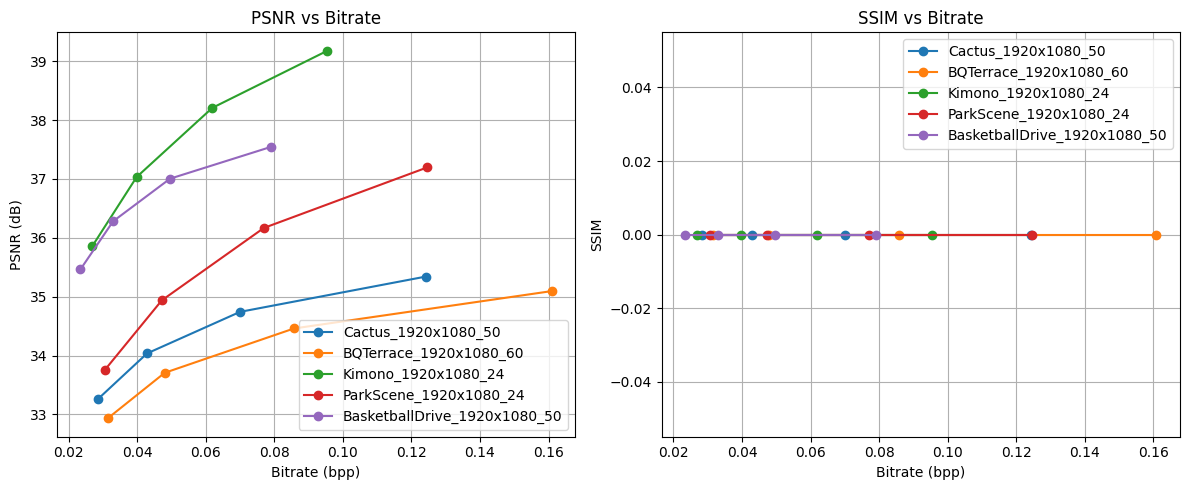

In [ ]:
import json
import matplotlib.pyplot as plt

results_path = "/kaggle/working/results_dcvc_dc.json"
with open(results_path) as f:
    results = json.load(f)

dataset = results["HEVC_B"]
sequences = list(dataset.keys())

plt.figure(figsize=(12, 5))

#  PSNR vs Bitrate
plt.subplot(1, 2, 1)
for seq in sequences:
    seq_data = dataset[seq]
    rate_idxs = sorted(seq_data.keys())  # "rate_000", "rate_001", ...
    bitrates = [seq_data[r]["ave_all_frame_bpp"] for r in rate_idxs]
    psnr = [seq_data[r]["ave_all_frame_psnr"] for r in rate_idxs]
    plt.plot(bitrates, psnr, marker='o', label=seq)

plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs Bitrate")
plt.grid(True)
plt.legend()

#  SSIM vs Bitrate
plt.subplot(1, 2, 2)
for seq in sequences:
    seq_data = dataset[seq]
    rate_idxs = sorted(seq_data.keys())
    bitrates = [seq_data[r]["ave_all_frame_bpp"] for r in rate_idxs]
    
    #  Vérifier si 'msssim' ou 'ssim' existe
    if "ave_all_frame_msssim" in seq_data[rate_idxs[0]]:
        ssim_values = [seq_data[r]["ave_all_frame_msssim"] for r in rate_idxs]
    else:
        ssim_values = [seq_data[r]["ave_all_frame_ssim"] for r in rate_idxs]
    
    plt.plot(bitrates, ssim_values, marker='o', label=seq)

plt.xlabel("Bitrate (bpp)")
plt.ylabel("SSIM")
plt.title("SSIM vs Bitrate")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import json
import os
import numpy as np

result_file = '/kaggle/working/results_dcvc_dc.json'

print("📊 DETAILED DCVC-DC RESULTS")
print("="*75)
print(f"{'Video':<30} | {'BPP (avg)':<15} | {'PSNR (avg)':<15}")
print("-" * 75)

if os.path.exists(result_file):
    with open(result_file, 'r') as f:
        data = json.load(f)
    
    # HEVC_B dataset
    if "HEVC_B" in data:
        dataset_data = data["HEVC_B"]
        
        global_bpp = []
        global_psnr = []
        
        for seq_name, rate_data in dataset_data.items():
            seq_bpps = []
            seq_psnrs = []
            
            for rate_idx, metrics in rate_data.items():
                #  Vérifier les clés possibles
                if 'frame_bpp' in metrics and 'frame_psnr' in metrics:
                    avg_bpp = np.mean(metrics['frame_bpp'])
                    avg_psnr = np.mean(metrics['frame_psnr'])
                elif 'ave_all_frame_bpp' in metrics and 'ave_all_frame_psnr' in metrics:
                    avg_bpp = metrics['ave_all_frame_bpp']
                    avg_psnr = metrics['ave_all_frame_psnr']
                else:
                    continue  # ignorer si les clés n’existent pas
                seq_bpps.append(avg_bpp)
                seq_psnrs.append(avg_psnr)
            
            if seq_bpps:
                seq_avg_bpp = np.mean(seq_bpps)
                seq_avg_psnr = np.mean(seq_psnrs)
                print(f"{seq_name[:30]:<30} | {seq_avg_bpp:<15.4f} | {seq_avg_psnr:<15.2f} dB")
                global_bpp.append(seq_avg_bpp)
                global_psnr.append(seq_avg_psnr)
        
        print("-" * 75)
        if global_bpp:
            final_bpp = np.mean(global_bpp)
            final_psnr = np.mean(global_psnr)
            print(f"{'TOTAL AVERAGE':<30} | {final_bpp:<15.4f} | {final_psnr:<15.2f} dB")
            print("="*75)
    else:
        print("❌ Unexpected structure: 'HEVC_B' key not found.")
else:
    print("❌ File not found.")


📊 DETAILED DCVC-DC RESULTS
Video                          | BPP (avg)       | PSNR (avg)     
---------------------------------------------------------------------------
Cactus_1920x1080_50            | 0.0664          | 34.34           dB
BQTerrace_1920x1080_60         | 0.0815          | 34.05           dB
Kimono_1920x1080_24            | 0.0560          | 37.57           dB
ParkScene_1920x1080_24         | 0.0698          | 35.52           dB
BasketballDrive_1920x1080_50   | 0.0463          | 36.57           dB
---------------------------------------------------------------------------
TOTAL AVERAGE                  | 0.0640          | 35.61           dB


📊 GENERATING R-D CURVES FOR DCVC-DC...
   🔹 Cactus          : 4 points plotted.
   🔹 BQTerrace       : 4 points plotted.
   🔹 Kimono          : 4 points plotted.
   🔹 ParkScene       : 4 points plotted.
   🔹 BasketballDrive : 4 points plotted.
✅ Graph saved : /kaggle/working/rd_curves_dcvc_dc.png


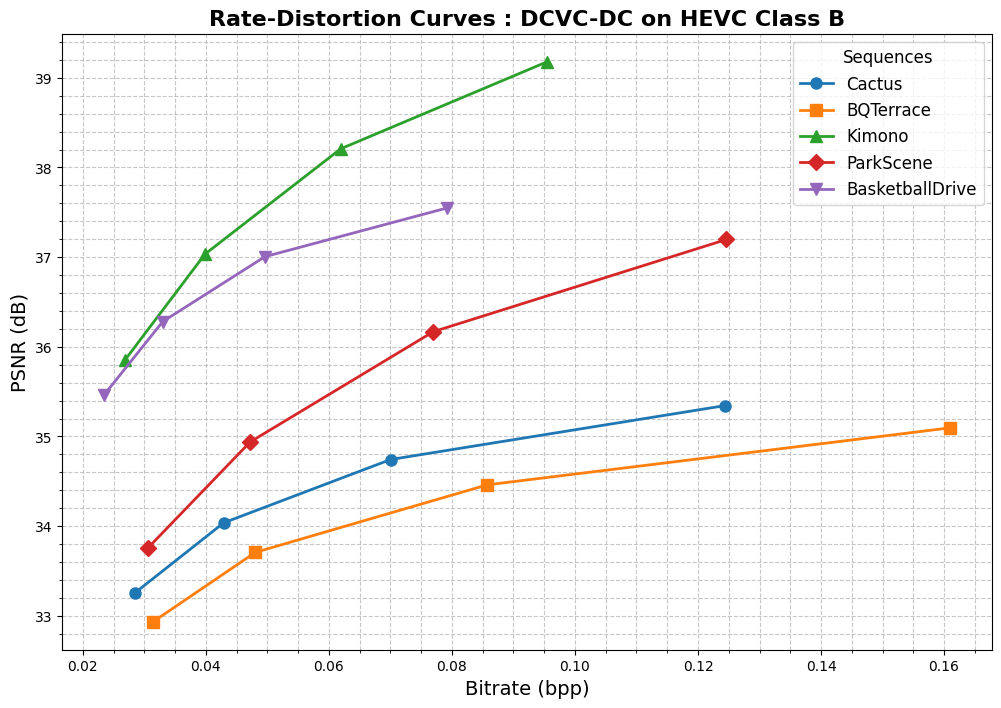

In [18]:
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# --- CONFIGURATION ---
RESULT_FILE = '/kaggle/working/results_dcvc_dc.json'

print("📊 GENERATING R-D CURVES FOR DCVC-DC...")
print("="*60)

plot_data = {}

if os.path.exists(RESULT_FILE):
    with open(RESULT_FILE, 'r') as f:
        data = json.load(f)
    
    if "HEVC_B" in data:
        for seq_name, rate_data in data["HEVC_B"].items():
            seq_bpps = []
            seq_psnrs = []
            
            # Loop over rate points
            for rate_idx, metrics in rate_data.items():
                if 'ave_all_frame_bpp' in metrics and 'ave_all_frame_psnr' in metrics:
                    avg_bpp = metrics['ave_all_frame_bpp']
                    avg_psnr = metrics['ave_all_frame_psnr']
                    seq_bpps.append(avg_bpp)
                    seq_psnrs.append(avg_psnr)
            
            if seq_bpps:
                plot_data[seq_name] = {
                    'bpp': seq_bpps,
                    'psnr': seq_psnrs
                }

# 2. Plotting
plt.figure(figsize=(12, 8))
markers = ['o', 's', '^', 'D', 'v']

for i, (seq_name, values) in enumerate(plot_data.items()):
    indices = np.argsort(values['bpp'])
    bpp_sorted = np.array(values['bpp'])[indices]
    psnr_sorted = np.array(values['psnr'])[indices]
    
    short_name = seq_name.split('_')[0]
    marker = markers[i % len(markers)]
    plt.plot(bpp_sorted, psnr_sorted, marker=marker, linewidth=2, markersize=8, label=short_name)
    
    print(f"   🔹 {short_name:<15} : {len(bpp_sorted)} points plotted.")

# 3. Styling the plot
plt.title('Rate-Distortion Curves : DCVC-DC on HEVC Class B', fontsize=16, fontweight='bold')
plt.xlabel('Bitrate (bpp)', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=12, title="Sequences", title_fontsize=12)
plt.minorticks_on()

# Save figure
output_img = '/kaggle/working/rd_curves_dcvc_dc.png'
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print("="*60)
print(f"✅ Graph saved : {output_img}")
plt.show()


In [ ]:
cp -r /kaggle/input/opendcvc/pytorch/default/1/opendcvcs-main-DCVC-family/opendcvcs-main-DCVC-family/DCVC-family/DCVC-DC /kaggle/working/DCVC-DC


In [34]:
import os

def print_tree(root_dir, prefix=""):
    """Print full directory tree."""
    contents = sorted(os.listdir(root_dir))
    pointers = ['├── '] * (len(contents) - 1) + ['└── ']
    for pointer, name in zip(pointers, contents):
        path = os.path.join(root_dir, name)
        print(prefix + pointer + name)
        if os.path.isdir(path):
            extension = '│   ' if pointer == '├── ' else '    '
            print_tree(path, prefix=prefix+extension)


project_root = "/kaggle/input/opendcvc/pytorch/default/1/opendcvcs-main-DCVC-family/opendcvcs-main-DCVC-family/DCVC-family/DCVC-DC"
print_tree(project_root)


├── README.md
├── checkpoints
│   └── download.py
├── dataset_config_example_rgb.json
├── dataset_config_example_yuv420.json
├── preprocessing.py
├── read_result.py
├── src
│   ├── cpp
│   │   ├── 3rdparty
│   │   │   ├── CMakeLists.txt
│   │   │   ├── pybind11
│   │   │   │   ├── CMakeLists.txt
│   │   │   │   └── CMakeLists.txt.in
│   │   │   └── ryg_rans
│   │   │       ├── CMakeLists.txt
│   │   │       └── CMakeLists.txt.in
│   │   ├── CMakeLists.txt
│   │   ├── ops
│   │   │   ├── CMakeLists.txt
│   │   │   └── ops.cpp
│   │   ├── py_rans
│   │   │   ├── CMakeLists.txt
│   │   │   ├── py_rans.cpp
│   │   │   └── py_rans.h
│   │   └── rans
│   │       ├── CMakeLists.txt
│   │       ├── rans.cpp
│   │       └── rans.h
│   ├── models
│   │   ├── common_model.py
│   │   ├── entropy_models.py
│   │   ├── image_model.py
│   │   ├── layers.py
│   │   ├── video_model.py
│   │   ├── video_model_ori.py
│   │   ├── video_model_transform.py
│   │   └── video_net.py
│   ├── transforms
│   │  

In [8]:
!pip install pytorch-msssim


In [47]:
import os

def print_dir_tree(root_dir, prefix=""):
    """Affiche l'arborescence des fichiers et dossiers"""
    if not os.path.exists(root_dir):
        print(f"Le dossier {root_dir} n'existe pas.")
        return

    entries = sorted(os.listdir(root_dir))
    for i, entry in enumerate(entries):
        path = os.path.join(root_dir, entry)
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(prefix + connector + entry)
        if os.path.isdir(path):
            extension = "    " if i == len(entries) - 1 else "│   "
            print_dir_tree(path, prefix + extension)

# Exemple d'utilisation
print_dir_tree("/kaggle/working")


├── .virtual_documents
│   └── __notebook_source__.ipynb
├── HEVC-B
│   └── png_sequences
│       ├── BQTerrace_1920x1080_60
│       │   ├── im00001.png
│       │   ├── im00002.png
│       │   ├── im00003.png
│       │   ├── im00004.png
│       │   ├── im00005.png
│       │   ├── im00006.png
│       │   ├── im00007.png
│       │   ├── im00008.png
│       │   ├── im00009.png
│       │   ├── im00010.png
│       │   ├── im00011.png
│       │   ├── im00012.png
│       │   ├── im00013.png
│       │   ├── im00014.png
│       │   ├── im00015.png
│       │   ├── im00016.png
│       │   ├── im00017.png
│       │   ├── im00018.png
│       │   ├── im00019.png
│       │   ├── im00020.png
│       │   ├── im00021.png
│       │   ├── im00022.png
│       │   ├── im00023.png
│       │   ├── im00024.png
│       │   ├── im00025.png
│       │   ├── im00026.png
│       │   ├── im00027.png
│       │   ├── im00028.png
│       │   ├── im00029.png
│       │   ├── im00030.png
│       │   ├── im00031.png
│      

In [ ]:
import traceback
import logging

logging.basicConfig(filename="dcvc_prof_errors.log",
                    level=logging.WARNING,
                    format="%(asctime)s %(levelname)s: %(message)s")

# --- PSNR sécurisé ---
def PSNR(input1, input2):
    # input1, input2 : tensors with values in [0,1]
    mse = torch.mean((input1 - input2) ** 2)
    mse_val = float(mse.item())
    if mse_val == 0.0:
        return float('inf')
    return (20 * torch.log10(1.0 / torch.sqrt(mse))).item()

def move_dpb_to_device(dpb, device):
    # ensure tensors in dpb live on the right device
    for k,v in dpb.items():
        if torch.is_tensor(v):
            dpb[k] = v.to(device)
    return dpb

def safe_get_q(video_net, *args, default_tuple=(None,None,None,None)):
    try:
        q_out = video_net.get_q_for_inference(*args)
        # ensure tuple-like and length >=4; pad if needed
        if isinstance(q_out, (list,tuple)):
            q = list(q_out) + [None]*max(0, 4-len(q_out))
            return tuple(q[:4])
        else:
            return default_tuple
    except Exception:
        return default_tuple

# --- Fonction de profiling robustifiée ---
def run_professional_profile(video_net, i_frame_net, args, device,
                             warmup_frames=2, save_json="dcvc_prof_per_frame.json",
                             save_csv="dcvc_prof_summary.csv"):
    frame_num = args['frame_num']
    gop_size = args['gop_size']
    verbose = args.get('verbose', 1)

    STAGES = [
        "I-frame",
        "Motion_estimation",
        "MV_encoding",
        "MV_hyperprior",
        "Motion_compensation",
        "Temporal_prior",
        "Spatial_prior",
        "Reconstruction"
    ]

    stage_totals = OrderedDict((s, 0.0) for s in STAGES)
    stage_counts = OrderedDict((s, 0) for s in STAGES)
    stage_max = OrderedDict((s, 0.0) for s in STAGES)

    per_frame_results = []
    src_reader = PNGReader(args['img_path'], args['src_width'], args['src_height'])

    dpb = {"ref_frame": None, "ref_feature": None, "ref_y": None, "ref_mv_feature": None, "ref_mv_y": None}

    # Warm-up
    if warmup_frames > 0:
        if verbose:
            print(f"Warm-up ({warmup_frames} frames) ...")
        for i in range(min(warmup_frames, frame_num)):
            rgb = src_reader.read_one_frame(dst_format="rgb")
            if rgb is None:
                break
            x = np_image_to_tensor(rgb).to(device)
            pic_h, pic_w = x.shape[2], x.shape[3]
            padding_l, padding_r, padding_t, padding_b = get_padding_size(pic_h, pic_w)
            x_padded = F.pad(x, (padding_l, padding_r, padding_t, padding_b))
            with torch.no_grad():
                try:
                    if i % gop_size == 0:
                        _ = i_frame_net.encode_decode(x_padded, q_in_ckpt=True, q_index=0,
                                                      output_path=None, pic_width=pic_w, pic_height=pic_h)
                    else:
                        res = None
                        try:
                            res = video_net.encode_decode(x_padded, dpb, q_in_ckpt=True, q_index=0,
                                                          output_path=None, pic_width=pic_w, pic_height=pic_h, frame_idx=i)
                        except Exception:
                            try:
                                res = video_net.forward_one_frame(x_padded, dpb, q_in_ckpt=True, q_index=0, frame_idx=i)
                            except Exception:
                                # warmup: ignore
                                pass
                        if isinstance(res, dict) and 'dpb' in res:
                            dpb = res['dpb']
                except Exception as e:
                    logging.warning("Warmup exception: " + repr(e))
                    if verbose:
                        print("Warmup exception (see dcvc_prof_errors.log)")

        src_reader.close()
        src_reader = PNGReader(args['img_path'], args['src_width'], args['src_height'])

    start_all = safe_time()
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=False,
        with_stack=False,
        profile_memory=True
    ) as prof:
        with torch.no_grad():
            for frame_idx in range(frame_num):
                frame_start = safe_time()
                rgb = src_reader.read_one_frame(dst_format="rgb")
                if rgb is None:
                    if verbose:
                        print(f"End of sequence at frame {frame_idx}")
                    break

                x = np_image_to_tensor(rgb).to(device)
                pic_h, pic_w = x.shape[2], x.shape[3]
                padding_l, padding_r, padding_t, padding_b = get_padding_size(pic_h, pic_w)
                x_padded = F.pad(x, (padding_l, padding_r, padding_t, padding_b))

                # make sure dpb tensors on device
                dpb = move_dpb_to_device(dpb, device)

                step_times = {}

                # get q args once
                q0, q1, q2, q3 = safe_get_q(video_net, True, 0)

                try:
                    if frame_idx % gop_size == 0:
                        t0 = safe_time()
                        with record_function("I-frame"):
                            result = i_frame_net.encode_decode(
                                x_padded,
                                q_in_ckpt=True,
                                q_index=0,
                                output_path=None,
                                pic_width=pic_w,
                                pic_height=pic_h
                            )
                        t1 = safe_time()
                        step_times["I-frame"] = t1 - t0

                        # store dpb tensors safely (clone & detach)
                        recon_frame = result.get("x_hat", None)
                        if torch.is_tensor(recon_frame):
                            recon_frame = recon_frame.clone().detach().to(device)
                        dpb = {
                            "ref_frame": recon_frame,
                            "ref_feature": None,
                            "ref_y": None,
                            "ref_mv_feature": None,
                            "ref_mv_y": None
                        }
                    else:
                        # P-frame pipeline
                        # 1) Motion_estimation
                        t0 = safe_time()
                        with record_function("Motion_estimation"):
                            est_mv = video_net.optic_flow(x_padded, dpb.get("ref_frame", None))
                        t1 = safe_time()
                        step_times["Motion_estimation"] = t1 - t0

                        # 2) MV_encoding
                        t0 = safe_time()
                        with record_function("MV_encoding"):
                            mv_y = None
                            try:
                                # handle both signatures
                                mv_q = q0 if q0 is not None else 0
                                mv_y = video_net.mv_encoder(est_mv, dpb.get("ref_mv_feature", None), mv_q)
                            except TypeError:
                                try:
                                    mv_y = video_net.mv_encoder(est_mv)
                                except Exception as e:
                                    mv_y = None
                                    logging.warning(f"MV_encoding error frame {frame_idx}: {traceback.format_exc()}")
                        t1 = safe_time()
                        step_times["MV_encoding"] = t1 - t0

                        # 3) MV_hyperprior (best-effort)
                        t0 = safe_time()
                        with record_function("MV_hyperprior"):
                            try:
                                if mv_y is not None:
                                    mv_z = video_net.mv_hyper_prior_encoder(mv_y if hasattr(mv_y, 'size') else mv_y)
                                    mv_z_hat = torch.round(mv_z)
                                    mv_params = video_net.mv_hyper_prior_decoder(mv_z_hat)
                                    ref_mv_y = dpb.get("ref_mv_y", None)
                                    if ref_mv_y is None:
                                        if hasattr(video_net, "mv_y_prior_fusion_adaptor_0"):
                                            mv_params = video_net.mv_y_prior_fusion_adaptor_0(mv_params)
                                    else:
                                        mv_params = torch.cat((mv_params, ref_mv_y), dim=1)
                                        if hasattr(video_net, "mv_y_prior_fusion_adaptor_1"):
                                            mv_params = video_net.mv_y_prior_fusion_adaptor_1(mv_params)
                                    if hasattr(video_net, "mv_y_prior_fusion"):
                                        mv_params = video_net.mv_y_prior_fusion(mv_params)
                            except Exception:
                                logging.warning(f"MV_hyperprior error frame {frame_idx}: {traceback.format_exc()}")
                        t1 = safe_time()
                        step_times["MV_hyperprior"] = t1 - t0

                        # 4) Motion_compensation
                        t0 = safe_time()
                        with record_function("Motion_compensation"):
                            mv_hat = None
                            mv_feature = None
                            try:
                                # try decoding mv (rounded if available)
                                if mv_y is not None:
                                    mv_hat, mv_feature = video_net.mv_decoder(torch.round(mv_y), q1) if q1 is not None else video_net.mv_decoder(torch.round(mv_y))
                                else:
                                    mv_hat, mv_feature = video_net.mv_decoder(est_mv, q1) if q1 is not None else video_net.mv_decoder(est_mv)
                                context1, context2, context3, warpframe = video_net.motion_compensation(dpb, mv_hat, frame_idx)
                            except Exception:
                                # log and try alternative motion_compensation signatures
                                logging.warning(f"Motion_compensation error frame {frame_idx}: {traceback.format_exc()}")
                                try:
                                    # fallback signature attempts
                                    out = video_net.motion_compensation(dpb.get("ref_frame", None), mv_hat, frame_idx)
                                    if isinstance(out, (list,tuple)):
                                        context1, context2, context3, warpframe = out
                                    else:
                                        context1 = context2 = context3 = warpframe = None
                                except Exception:
                                    context1 = context2 = context3 = warpframe = None
                        t1 = safe_time()
                        step_times["Motion_compensation"] = t1 - t0

                        # 5) Temporal_prior
                        t0 = safe_time()
                        with record_function("Temporal_prior"):
                            try:
                                temporal_params = video_net.temporal_prior_encoder(context3) if context3 is not None else None
                            except Exception:
                                temporal_params = None
                                logging.warning(f"Temporal_prior error frame {frame_idx}: {traceback.format_exc()}")
                        t1 = safe_time()
                        step_times["Temporal_prior"] = t1 - t0

                        # 6) Spatial_prior (contextual encoder + hyperprior + prior fusion)
                        t0 = safe_time()
                        with record_function("Spatial_prior"):
                            y = None
                            hierarchical_params = None
                            params = None
                            y_hat = None
                            try:
                                y = video_net.contextual_encoder(x_padded, context1, context2, context3, q2)
                                try:
                                    z = video_net.contextual_hyper_prior_encoder(y)
                                    z_hat = torch.round(z)
                                    hierarchical_params = video_net.contextual_hyper_prior_decoder(z_hat)
                                except Exception:
                                    hierarchical_params = None
                                ref_y = dpb.get("ref_y", None)
                                params_list = []
                                if temporal_params is not None:
                                    params_list.append(temporal_params)
                                if hierarchical_params is not None:
                                    params_list.append(hierarchical_params)
                                if ref_y is not None:
                                    params_list.append(ref_y)
                                if len(params_list) > 0:
                                    params_cat = torch.cat(params_list, dim=1)
                                    try:
                                        params = video_net.y_prior_fusion(params_cat)
                                    except Exception:
                                        params = params_cat
                                # try forward_four_part_prior then fallback to dual prior
                                try:
                                    if params is not None:
                                        _, y_q, y_hat, scales_hat = video_net.forward_four_part_prior(
                                            y, params,
                                            getattr(video_net, "y_spatial_prior_adaptor_1", None),
                                            getattr(video_net, "y_spatial_prior_adaptor_2", None),
                                            getattr(video_net, "y_spatial_prior_adaptor_3", None),
                                            getattr(video_net, "y_spatial_prior", None)
                                        )
                                    else:
                                        # fallback: try dual prior
                                        mv = None
                                        y_res, y_q, y_hat, scales_hat = video_net.forward_dual_prior(
                                            y, None, None, None, getattr(video_net, "y_spatial_prior", None)
                                        )
                                except Exception:
                                    # if prior steps fail, leave y_hat None and continue to reconstruction fallback
                                    logging.warning(f"Spatial_prior internals failed frame {frame_idx}: {traceback.format_exc()}")
                            except Exception:
                                logging.warning(f"Spatial_prior error frame {frame_idx}: {traceback.format_exc()}")
                        t1 = safe_time()
                        step_times["Spatial_prior"] = t1 - t0

                        # 7) Reconstruction
                        t0 = safe_time()
                        with record_function("Reconstruction"):
                            try:
                                if y_hat is not None:
                                    recon_feature = video_net.contextual_decoder(y_hat, context2, context3, q3)
                                    feature, x_hat = video_net.recon_generation_net(recon_feature, context1)
                                else:
                                    # try alternate convenience method if present
                                    try:
                                        x_hat, feature = video_net.get_recon_and_feature(y_hat, context1, context2, context3, q3)
                                    except Exception:
                                        x_hat = None
                                        feature = None
                            except Exception:
                                logging.warning(f"Reconstruction error frame {frame_idx}: {traceback.format_exc()}")
                                x_hat = None
                                feature = None
                        t1 = safe_time()
                        step_times["Reconstruction"] = t1 - t0

                        # final fallback strategy (avoid x_hat == x_padded if possible)
                        if x_hat is None:
                            # prefer last recon in dpb if shapes match
                            last_ref = dpb.get("ref_frame", None)
                            if torch.is_tensor(last_ref) and last_ref.shape == x_padded.shape:
                                x_hat = last_ref.clone().detach()
                            else:
                                # as absolute last resort, use input (previous behavior)
                                x_hat = x_padded.clone().detach()

                        recon_frame = x_hat
                        dpb = {
                            "ref_frame": recon_frame.clone().detach() if torch.is_tensor(recon_frame) else recon_frame,
                            "ref_feature": feature if 'feature' in locals() else None,
                            "ref_mv_feature": mv_feature if 'mv_feature' in locals() else None,
                            "ref_y": y_hat if 'y_hat' in locals() else None,
                            "ref_mv_y": mv_y if 'mv_y' in locals() else None
                        }

                except Exception as outer_e:
                    # top-level frame error: log and continue with input as fallback
                    logging.error(f"Top-level frame {frame_idx} exception:\n{traceback.format_exc()}")
                    if verbose:
                        print(f"Exception on frame {frame_idx} (see dcvc_prof_errors.log)")
                    recon_frame = x_padded
                    # dpb remains as-is

                # clamp & unpad, compute metrics
                try:
                    recon_frame = recon_frame.clamp_(0, 1)
                except Exception:
                    # if recon_frame not tensor, force set to input
                    recon_frame = x_padded.clone().detach()

                # unpad
                x_hat = F.pad(recon_frame, (-padding_l, -padding_r, -padding_t, -padding_b))
                # compute a small diagnostic: l2 norm
                diff_norm = float(torch.norm(x_hat - x).item())

                psnr_val = PSNR(x_hat, x)
                ms_ssim_val = ms_ssim(x_hat, x, data_range=1).item()

                frame_time = safe_time() - frame_start

                per_frame_results.append({
                    "frame_idx": frame_idx,
                    "psnr": float(psnr_val) if not np.isnan(psnr_val) else None,
                    "ms_ssim": float(ms_ssim_val),
                    "frame_time": float(frame_time),
                    "steps_time": {k: float(v) for k,v in step_times.items()},
                    "diff_norm": diff_norm
                })

                for k,v in step_times.items():
                    if k in stage_totals:
                        stage_totals[k] += v
                        stage_counts[k] += 1
                        if v > stage_max[k]:
                            stage_max[k] = v

                if verbose >= 2:
                    summary = f"Frame {frame_idx}: {frame_time:.3f}s, PSNR={psnr_val:.2f}, MS-SSIM={ms_ssim_val:.4f}, ||diff||={diff_norm:.4f}"
                    print(summary)
                    for s,t in step_times.items():
                        print(f"  {s}: {t:.3f}s", end="")
                    print()

    total_all = safe_time() - start_all

    # Summarize
    summary_rows = []
    total_measured = sum(stage_totals.values()) if sum(stage_totals.values()) > 0 else 1.0
    for s in STAGES:
        total = stage_totals[s]
        count = stage_counts[s]
        avg = total / count if count > 0 else 0.0
        maxv = stage_max[s]
        pct = 100.0 * total / total_measured if total_measured > 0 else 0.0
        summary_rows.append({
            "stage": s,
            "total_time_s": total,
            "count": count,
            "avg_time_s": avg,
            "max_time_s": maxv,
            "pct_of_measured_time": pct
        })

    with open(save_json, "w") as f:
        json.dump({"frames": per_frame_results, "summary_total_time_s": total_all}, f, indent=2)

    with open(save_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["stage","total_time_s","count","avg_time_s","max_time_s","pct_of_measured_time"])
        writer.writeheader()
        for row in summary_rows:
            writer.writerow(row)

    print("\n=== Profiling Summary (aggregated over frames) ===")
    print(f"Total wall time (all frames): {total_all:.3f}s")
    print("{:30s} {:>10s} {:>8s} {:>10s} {:>10s}".format("Stage","Total(s)","Count","Avg(s)","Max(s)"))
    for r in sorted(summary_rows, key=lambda x: x["total_time_s"], reverse=True):
        print("{:30s} {:10.3f} {:8d} {:10.4f} {:10.4f}".format(r["stage"], r["total_time_s"], int(r["count"]), r["avg_time_s"], r["max_time_s"]))
    print(f"\nSaved per-frame JSON -> {save_json}")
    print(f"Saved summary CSV     -> {save_csv}")
    try:
        prof.export_chrome_trace("dcvc_prof_trace.json")
        print("Chrome trace saved as dcvc_prof_trace.json")
    except Exception:
        pass

    return per_frame_results, summary_rows
